In [15]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

In [7]:
df = pd.read_csv("data/spam.csv",encoding='latin-1')[['v1','v2']]
df.columns=['label','message']
df['label']=df['label'].map({'ham':0,'spam':1})
print(df.shape)
print(df['label'].value_counts())
print(df.head())

(5572, 2)
label
0    4825
1     747
Name: count, dtype: int64
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [13]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"AUC:       {roc_auc_score(y_test, y_prob):.3f}")

Accuracy:  0.978
Precision: 0.992
Recall:    0.840
F1:        0.910
AUC:       0.982


In [14]:
# Default threshold 0.5
print("--- Threshold 0.5 ---")
y_pred_05 = (y_prob >= 0.5).astype(int)
print(f"Precision: {precision_score(y_test, y_pred_05):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_05):.3f}")

# Lower threshold 0.3
print("\n--- Threshold 0.3 ---")
y_pred_03 = (y_prob >= 0.3).astype(int)
print(f"Precision: {precision_score(y_test, y_pred_03):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_03):.3f}")

# Even lower 0.1
print("\n--- Threshold 0.1 ---")
y_pred_01 = (y_prob >= 0.1).astype(int)
print(f"Precision: {precision_score(y_test, y_pred_01):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_01):.3f}")

--- Threshold 0.5 ---
Precision: 0.992
Recall:    0.840

--- Threshold 0.3 ---
Precision: 0.978
Recall:    0.907

--- Threshold 0.1 ---
Precision: 0.869
Recall:    0.927


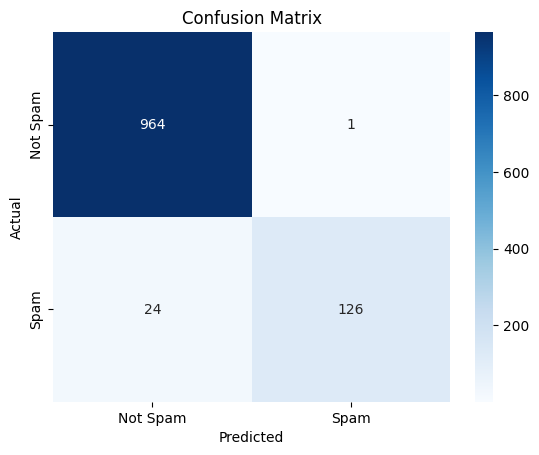

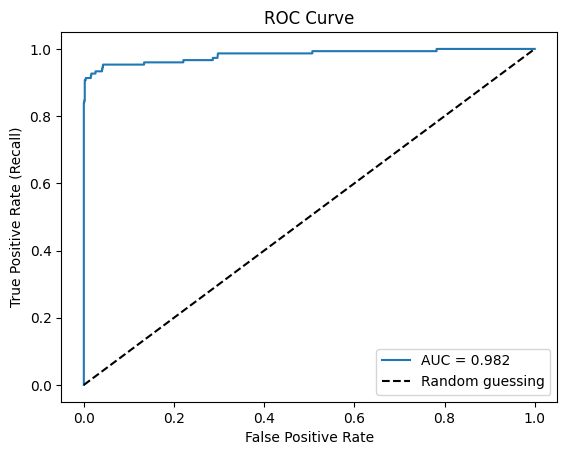

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = 0.982')
plt.plot([0,1], [0,1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# Accuracy hide truth on inbalance dataset
# Precision = TP / (TP + FP) it calculate based on predictions
# Recall = TP / (TP + FN) it calculate based on actual values